<div style="background-color: lightgray; padding: 10px;">

<div style="display: flex; align-items: center; gap: 20px;">
        <img src="https://www.rmag.org/graphics/design/RMAG-logo-2022.png" width="100">

<div style="font-weight: bold; font-size: 40px;align-items: center;">
            Python Skill Series
        </div>
    </div>

<div style="
        font-size: 30px;
        text-align: center;
        margin-top: 10px;
    ">Spatial Geoscience &amp; Analytics
</div>

<div style="
        font-size: 30px;
        text-align: center;
        margin-top: 10px;
    ">3D Rock Properties with Numpy & Model with Pyvista
</div>

</div>


[Patelke, Richard L, 2003. *Exploration Drill Hole Lithology, Geologic Unit, Copper-Nickel Assay, and Location Database for the Keweenawan Duluth Complex, Northeastern Minnesota*](https://conservancy.umn.edu/items/a42b4482-da74-4788-81b3-6a95f5b3ea8e)

In [21]:
!pip install pyvista[jupyter]
!pip install fast-simplification


  Attempting uninstall: trame-common

    Found existing installation: trame-common 1.2.1

    Uninstalling trame-common-1.2.1:

   ---------------------------------------- 0/4 [trame-common]
      Successfully uninstalled trame-common-1.2.1
   ---------------------------------------- 0/4 [trame-common]
   ---------------------------------------- 0/4 [trame-common]
   ---------------------------------------- 0/4 [trame-common]
   ---------------------------------------- 0/4 [trame-common]
  Attempting uninstall: trame-client
   ---------------------------------------- 0/4 [trame-common]
    Found existing installation: trame-client 3.12.1
   ---------------------------------------- 0/4 [trame-common]
   ---------- ----------------------------- 1/4 [trame-client]
    Uninstalling trame-client-3.12.1:
   ---------- ----------------------------- 1/4 [trame-client]
   ---------- ----------------------------- 1/4 [trame-client]
      Successfully uninstalled trame-client-3.12.1
   --------

In [3]:
import pandas as pd
import geopandas as gpd
import pyvista as pv
import numpy as np
from shapely import Point, LineString
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import CloughTocher2DInterpolator, RegularGridInterpolator, LinearNDInterpolator
import scipy
from scipy.spatial import cKDTree
from numba import njit, prange
import fast_simplification

pd.set_option('display.max_columns', None)

In [4]:
@njit(cache=True, parallel=True)
def fill_nans_with_neighbors(array, mode='3d'):
    if mode == '3d':
        directions = [(-1, 0, 0), (1, 0, 0), (0, -1, 0), (0, 1, 0), (0, 0, -1), (0, 0, 1)]
    elif mode == 'xy':
        directions = [(-1, 0, 0), (1, 0, 0), (0, -1, 0), (0, 1, 0)]
    else:
        raise ValueError("Unsupported mode. Choose '3d' or 'xy'.")
        
    # Copy the input array to avoid modifying it directly
    filled_array = np.copy(array)
    
    # Get the dimensions of the array
    x_dim, y_dim, z_dim = filled_array.shape
    
    # Iterate over each index in the array
    for x in prange(x_dim):
        for y in prange(y_dim):
            for z in prange(z_dim):
                if np.isnan(filled_array[x, y, z]):
                    # Collect neighbors
                    neighbors = np.zeros(6)  # Array to store neighbor values
                    count = 0  # Counter for valid neighbors
                    
                    # Iterate over all 6 direct neighbors
                    for dx, dy, dz in directions:
                        nx, ny, nz = x + dx, y + dy, z + dz
                        # Check if the neighbor index is within bounds
                        if 0 <= nx < x_dim and 0 <= ny < y_dim and 0 <= nz < z_dim:
                            # Add non-NaN neighbors to the array
                            if not np.isnan(filled_array[nx, ny, nz]):
                                neighbors[count] = filled_array[nx, ny, nz]
                                count += 1
                    
                    # If we have neighbors, compute the average and fill the NaN
                    if count > 0:
                        filled_array[x, y, z] = np.sum(neighbors[:count]) / count
    
    return filled_array

In [5]:
# UTM 83
crs = 'EPSG:26915'
mdd = gpd.read_file("./data/Patelke2003/DULUTH-COMPLEX-SHAPEFILES/mddhhead.shp")
deposits = gpd.read_file("./data/Patelke2003/DULUTH-COMPLEX-SHAPEFILES/deposits.shp")

# no prj file, manually define crs
mdd.crs = crs
deposits.crs = crs

# Now lets change to NAD27 SP North so we are working in the same CRS later
crs = 'EPSG:26791'
mdd.to_crs(crs, inplace=True)
deposits.to_crs(crs, inplace=True)

mdd.head(2)

,HOLE_ID,INTRUSION,DEPOSIT,EASTUTM83,NORTHUTM83,COL_EL_FT,LENGTH_FT,OVB_THICK_,FWDEPTH_FT,AZIMUTH,DIP,COL_EL_MET,TOTDEPMETR,EASTUTM27,NORTHUTM27,EASTSP27,NORTHSP27,EASTSP83,NORTHSP83,COUNTY,QUAD,TOWNSHIP,RANGE,SECTION,FORTY,XLSFILE,GRIDCOMP,GRIDEAST,GRIDNORTH,LESSEE,GEOLOGIST,INITIAL_,SUR_UNDG,VERT_ANG,CORE_RC,DATE_DRILL,NRRI_SECT,COMP_SECT,BEST_REF,HEAD_COMM,LITH_COMM,ASSAY_COMM,SURV_COMM,SOURCEFILE,geometry
0,00-325B,PRI,DUNKA ROAD (NORTHMET),577043.25,5274521.0,1615.0,325.0,17.0,305.0,0,-90,492.3,99.06,577057.81,5274311.5,2277544.98,410378.56,2902163.0,738433.63,ST LOUIS,BABBITT SW,59N,13W,3,NaN,WEST,NaN,NS,NS,POLYMET,POLYMET ABANDONMENT REPORT,INITIAL,SURFACE,VERTICAL,RC,20000109.0,NOT CHECKED,NOT CHECKED,NONE-NO REPORTS PUBLIC-CONTACT POLYMET,NaN,NaN,NaN,NaN,WORKING-PMET-GEOL-ABAN.XLS,POINT (2277545.439 410378.522)
1,00-326C,PRI,DUNKA ROAD (NORTHMET),577067.38,5274319.0,1613.0,870.0,5.0,703.0,0,-90,491.6,265.18,577081.94,5274109.5,2277625.01,409716.37,2902243.0,737771.44,ST LOUIS,BABBITT SW,59N,13W,3,NaN,WEST,NaN,NS,NS,POLYMET,POLYMET ABANDONMENT REPORT,INITIAL,SURFACE,VERTICAL,CORE,20000118.0,NOT CHECKED,NOT CHECKED,NONE-NO REPORTS PUBLIC-CONTACT POLYMET,NaN,NaN,NaN,NaN,WORKING-PMET-GEOL-ABAN.XLS,POINT (2277625.532 409715.731)


In [6]:
## Borehole Sticks
path = "./data/Patelke2003/DULUTH-COMPLEX-CSV-FILES/SURVEY.csv"

surv = pd.read_csv(path)
surv.head()

,HOLE-ID,FROM,TO,LENGTH,AZIMUTH,DIP,SURVEYED,DATA-REF,DESURVFROMX,DESURVFROMY,DESURVFROMZ,DESURVTOX,DESURVTOY,DESURVTOZ,DEPOSIT,XLSFILE
0,00-325B,0.0,325.0,325.0,0.0,-90.0,NO SURVEY AVAILABLE,POLYMET ABANDONMENT REPORT,2277545.0,410378.6,1615.0,2277545.0,410378.6,1290.0,DUNKA ROAD (NORTHMET),WEST
1,00-326C,0.0,870.0,870.0,0.0,-90.0,NO SURVEY AVAILABLE,POLYMET ABANDONMENT REPORT,2277625.0,409716.4,1613.0,2277625.0,409716.4,743.0,DUNKA ROAD (NORTHMET),WEST
2,00-327C,0.0,500.0,500.0,0.0,-90.0,NO SURVEY AVAILABLE,POLYMET ABANDONMENT REPORT,2278494.0,410798.5,1609.0,2278494.0,410798.5,1109.0,DUNKA ROAD (NORTHMET),WEST
3,00-328B,0.0,305.0,305.0,0.0,-90.0,NO SURVEY AVAILABLE,POLYMET ABANDONMENT REPORT,2277405.0,410369.7,1616.0,2277405.0,410369.7,1311.0,DUNKA ROAD (NORTHMET),WEST
4,00-329B,0.0,385.0,385.0,0.0,-90.0,NO SURVEY AVAILABLE,POLYMET ABANDONMENT REPORT,2277715.0,410479.8,1611.0,2277715.0,410479.8,1226.0,DUNKA ROAD (NORTHMET),WEST


In [7]:
names = []
geometries = []

#Make Sticks from Surveys
for bhname, group in surv.groupby('HOLE-ID'):

    ## Dataset has the From and To core descriptions, let's use those
    fromxyz = group[['DESURVFROMX','DESURVFROMY','DESURVFROMZ']].values
    toxyz = group[['DESURVTOX','DESURVTOY','DESURVTOZ']].values
    
    # Interweave the From - To and drop duplicates to make our lines
    merged = np.empty((fromxyz.shape[0] * 2, 3), dtype=fromxyz.dtype)
    merged[0::2] = fromxyz
    merged[1::2] = toxyz
    
    # Remove repeated coordinates while preserving order
    unique = np.array(list(dict.fromkeys(map(tuple, merged))))
    
    # Make geometry
    geom = LineString(unique)
    
    names.append(bhname)
    geometries.append(geom)
    print('.', end='')

crs = 'EPSG:26791' # State Plane NAD27
boreholes = gpd.GeoDataFrame({'HOLE-ID':names, 'geometry':geometries}, crs=crs)

boreholes.head(2)

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

,HOLE-ID,geometry
0,00-325B,"LINESTRING Z (2277545 410378.6 1615, 2277545 4..."
1,00-326C,"LINESTRING Z (2277625 409716.4 1613, 2277625 4..."


In [8]:
# Save Boreholes Out
boreholes.to_file('./data/Patelke2003/BH_lines.gpkg')

<Axes: >

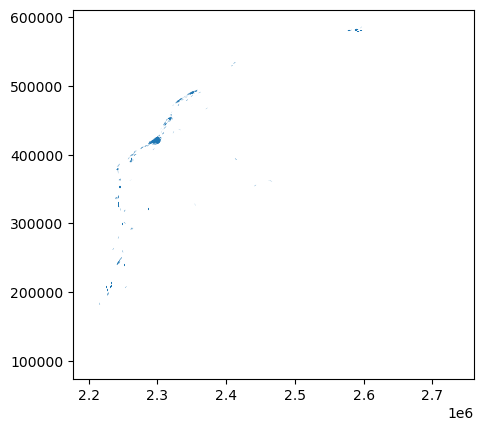

In [9]:
# Preview Data
boreholes.plot()

In [11]:
## Analysis
path = "./data/Patelke2003/DULUTH-COMPLEX-CSV-FILES/PGE-ETC.csv"

test = pd.read_csv(path)

# Format strings to float
cols = list(test)[9:32]
test[cols] = test[cols].replace('NS',np.nan).astype(float)
test.head()

,HOLE-ID,FROM,TO,INT-AS-TXT,LENGTH,INTRUSION,UNIT,ROCKTYPE,DEPOSIT,AU-PPB,PT-PPB,PD-PPB,CU-PPM,NI-PPM,S%,CO-PPM,ZN-PPM,AG-PPM,AU-PPM,AS-PPM,CR-PPM,TIO2%,TI%,MGO%,MG%,CR2O3%,CL-PPM,MO-PPM,V-PPM,CU/PD,CU%,NI%,REFERENCE,DESURVFROMX,DESURVFROMY,DESURVFROMZ,DESURVTOX,DESURVTOY,DESURVTOZ,XLSFILE
0,26010,25.0,35.0,25-35,10.0,PRI,I,Augite Troct,Dunka Road,57.0,267.0,852.0,3828.0,1157.0,0.86,61.0,82.0,1.2,NaN,6.0,24.0,NaN,0.10,NaN,NaN,NaN,NaN,NaN,22.0,4493.0,0.38,0.12,Geerts - 1991,2276794.2,409177.0,1582.8,2276789.6,409181.5,1575.2,WEST
1,26010,53.0,63.0,53-63,10.0,PRI,I,Anorth Troct,Dunka Road,6.0,8.0,15.0,251.0,240.0,0.14,39.0,68.0,0.1,NaN,6.0,45.0,NaN,0.08,NaN,NaN,NaN,NaN,NaN,25.0,16733.0,0.03,0.02,Geerts - 1991,2276781.5,409189.7,1561.4,2276776.9,409194.2,1553.7,WEST
2,26010,90.0,95.0,90-95,5.0,PRI,I,Anorth Troct,Dunka Road,1.0,5.0,8.0,192.0,220.0,NaN,37.0,48.0,0.4,NaN,1.0,58.0,NaN,0.07,NaN,NaN,NaN,NaN,NaN,21.0,24000.0,0.02,0.02,Geerts - 1991,2276764.6,409206.5,1533.1,2276762.4,409208.8,1529.2,WEST
3,26010,95.0,100.0,95-100,5.0,PRI,I,Anorth Troct,Dunka Road,1.0,1.0,5.0,400.0,196.0,NaN,41.0,56.0,0.5,NaN,3.0,40.0,NaN,0.06,NaN,NaN,NaN,NaN,NaN,16.0,80000.0,0.04,0.02,Geerts - 1991,2276762.4,409208.8,1529.2,2276760.1,409211.1,1525.4,WEST
4,26010,100.0,105.0,100-105,5.0,PRI,I,Anorth Troct,Dunka Road,6.0,1.0,3.0,147.0,138.0,NaN,37.0,52.0,0.4,NaN,1.0,38.0,NaN,0.05,NaN,NaN,NaN,NaN,NaN,15.0,49000.0,0.01,0.01,Geerts - 1991,2276760.1,409211.1,1525.4,2276757.8,409213.3,1521.6,WEST


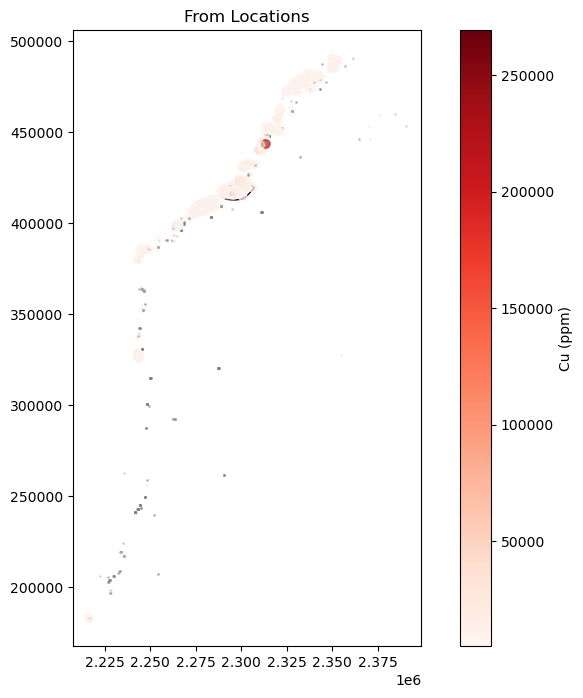

In [13]:
# "From" locations to preview data
gdf = gpd.GeoDataFrame(test, geometry=gpd.points_from_xy(test.DESURVFROMX, test.DESURVFROMY, test.DESURVFROMZ), crs= crs)

# Preview Locations
fig, ax = plt.subplots(figsize=(10, 8))

deposits[:1].plot(facecolor='white', edgecolor='k', ax=ax)
gdf.plot(color='grey', markersize=1, alpha=0.1, ax=ax)

gdf[gdf['CU-PPM'] > 5000].plot(
    column="CU-PPM",
    cmap="Reds",
    alpha=0.3,
    legend=True,
    ax=ax,
    legend_kwds={"label": "Cu (ppm)"}
)

ax.set_title("From Locations")
plt.show()


In [14]:
# Save out for preview in Q
gdf.to_file('./data/Patelke2003/PGE-ETC.gpkg')

<Axes: >

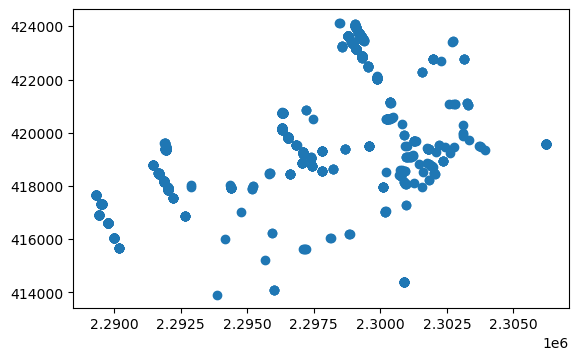

In [15]:
## Let's work with a smaller dataset and build a block model

# BABBITT (MESABA) DEPOSIT
geom = deposits.at[0,'geometry']
select = gdf[gdf.intersects(geom)].copy()

select.plot()

In [16]:
## Get values to build voxel
xyz = np.concatenate([select[['DESURVFROMX','DESURVFROMY','DESURVFROMZ']].values, 	
                      select[['DESURVTOX','DESURVTOY','DESURVTOZ']].values])

xmin = xyz[:,0].min()
xmax = xyz[:,0].max()

ymin = xyz[:,1].min()
ymax = xyz[:,1].max()

zmin = xyz[:,2].min()
zmax = xyz[:,2].max()

dx = xmax - xmin
dy = ymax - ymin
dz = zmax - zmin

dx, dy, dz

(np.float64(16938.299999999814),
 np.float64(10207.100000000035),
 np.float64(3639.9))

<img src="https://www.markwrobel.dk/post/amiga-machine-code-letter12-linedraw/Bresenham-plotter.png" style="height: 400px;" alt="Description">


Since we have a beginning and end of the core we'll use a [Bresenham's Line](https://www.markwrobel.dk/post/amiga-machine-code-letter12-linedraw/) to achieve the indexing needed to assign the values to our voxel.

In [17]:
def bresenham3d(x1, y1, z1, x2, y2, z2):
    """
    Return integer voxel coordinates intersected by a 3D line.
    """

    x1, y1, z1 = map(int, (x1, y1, z1))
    x2, y2, z2 = map(int, (x2, y2, z2))

    points = []

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    dz = abs(z2 - z1)

    xs = 1 if x2 > x1 else -1
    ys = 1 if y2 > y1 else -1
    zs = 1 if z2 > z1 else -1

    x, y, z = x1, y1, z1

    if dx >= dy and dx >= dz:
        p1 = 2 * dy - dx
        p2 = 2 * dz - dx
        while x != x2:
            points.append((x, y, z))
            x += xs
            if p1 >= 0:
                y += ys
                p1 -= 2 * dx
            if p2 >= 0:
                z += zs
                p2 -= 2 * dx
            p1 += 2 * dy
            p2 += 2 * dz

    elif dy >= dx and dy >= dz:
        p1 = 2 * dx - dy
        p2 = 2 * dz - dy
        while y != y2:
            points.append((x, y, z))
            y += ys
            if p1 >= 0:
                x += xs
                p1 -= 2 * dy
            if p2 >= 0:
                z += zs
                p2 -= 2 * dy
            p1 += 2 * dx
            p2 += 2 * dz

    else:
        p1 = 2 * dy - dz
        p2 = 2 * dx - dz
        while z != z2:
            points.append((x, y, z))
            z += zs
            if p1 >= 0:
                y += ys
                p1 -= 2 * dz
            if p2 >= 0:
                x += xs
                p2 -= 2 * dz
            p1 += 2 * dy
            p2 += 2 * dx

    points.append((x2, y2, z2))

    return np.asarray(points)

In [18]:
# downsample factor (df)
df = 50 #Large makes a smaller but less detailed array, but easier to process

# You can use equal offsets -or- different (ie shrinking the horizontal plane more to give interpolation bias)
dfx = df
dfy = df
dfz = df

dim_x = int((xmax - xmin)/ dfx ) + 1
dim_y = int((ymax - ymin) / dfy ) + 1
dim_depth = int((zmax - zmin) / dfz) + 2
array_3d = np.full((dim_x, dim_y, dim_depth), np.nan)

for _, row in select[select['CU-PPM'].notnull()].iterrows():

    ix0 = int((row.DESURVFROMX - xmin) / dfx)
    iy0 = int((row.DESURVFROMY - ymin) / dfy)
    iz0 = int((row.DESURVFROMZ - zmin) / dfz)

    ix1 = int((row.DESURVTOX - xmin) / dfx)
    iy1 = int((row.DESURVTOY - ymin) / dfy)
    iz1 = int((row.DESURVTOZ - zmin) / dfz)

    voxels = bresenham3d(
        ix0, iy0, iz0,
        ix1, iy1, iz1
    )

    x, y, z = voxels.T

    valid = (
        (x >= 0) & (x < dim_x) &
        (y >= 0) & (y < dim_y) &
        (z >= 0) & (z < dim_depth)
    )

    array_3d[
        x[valid],
        y[valid],
        z[valid]
    ] = row['CU-PPM']
    print('.',end='') #k.i.s.s. status

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

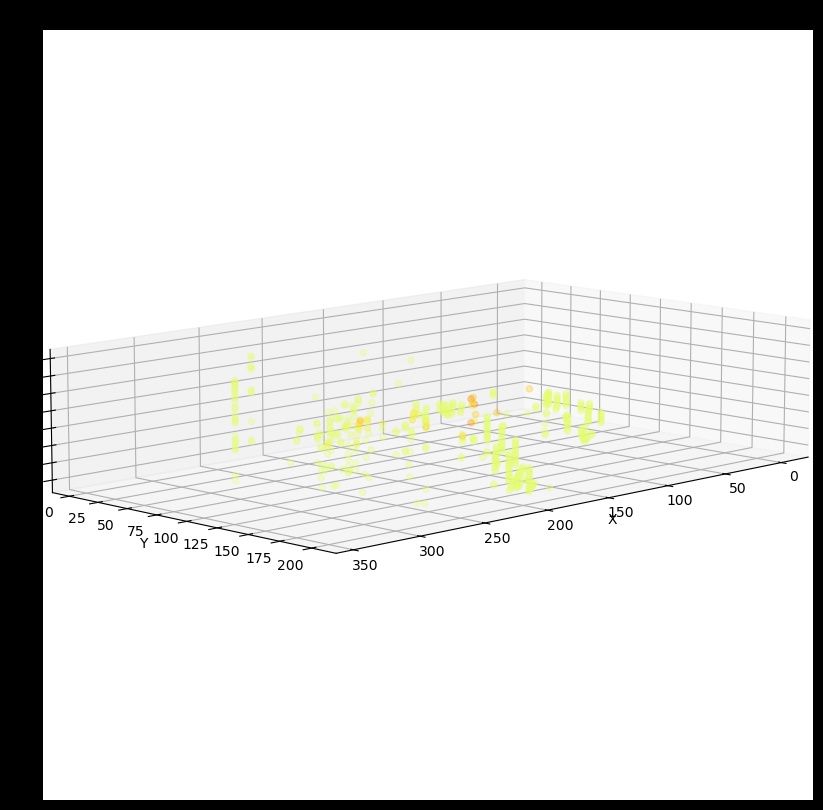

In [19]:
## Preview Data

# Find the indices of non-null values
non_nan_indices = np.where(~np.isnan(array_3d))

# Extract the non-null values
non_null_values = array_3d[non_nan_indices]

# non_nan_indices is a tuple of arrays representing the indices for each dimension
x_indices, y_indices, z_indices = non_nan_indices

# Convert indices to lists
xval = x_indices.tolist()
yval = y_indices.tolist()
zval = z_indices.tolist()
mval = non_null_values

fig = plt.figure(figsize=(15,10))
fig.patch.set_facecolor('black')
ax1 = fig.add_subplot(111, projection='3d')
ax1.set_title("Original Cu Data")
ax1.scatter(xval,yval,zval, c=mval, cmap='Wistia', alpha=0.3)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.invert_zaxis()
ax1.view_init(elev=10, azim=45
             )
ax1.set_aspect('equal')


In [20]:
# Works on larger Arrays

# Known voxels
non_nan = np.where(~np.isnan(array_3d))

points = np.column_stack(non_nan).astype(np.float32)
values = array_3d[non_nan].astype(np.float32)

# Build tree
tree = cKDTree(points)

# Query grid
xs, ys, zs = array_3d.shape

X, Y, Z = np.meshgrid(
    np.arange(xs),
    np.arange(ys),
    np.arange(zs),
    indexing="ij"
)

query_points = np.column_stack([
    X.ravel(),
    Y.ravel(),
    Z.ravel()
]).astype(np.float32)

# Find k nearest neighbors
k = 8

dist, idx = tree.query(
    query_points,
    k=k,
    workers=-1
)

# Avoid division by zero
dist = np.maximum(dist, 1e-12)

# IDW weights
power = 2

weights = 1.0 / dist**power
weights /= weights.sum(axis=1, keepdims=True)

# Weighted average
interp = np.sum(
    values[idx] * weights,
    axis=1
)

interpolated_values = interp.reshape(array_3d.shape)

In [42]:
# Works for small arrays
small = False
if small:
    ## Linear Interpolate Values in array 3d
    # Find the indices of non-null values
    non_nan_indices = np.where(~np.isnan(array_3d))
    
    # Extract the non-null values
    non_null_values = array_3d[non_nan_indices]
    
    # non_nan_indices is a tuple of arrays representing the indices for each dimension
    x_indices, y_indices, z_indices = non_nan_indices
    
    # Convert indices to lists
    xval = x_indices.tolist()
    yval = y_indices.tolist()
    zval = z_indices.tolist()
    mval = array_3d[non_nan_indices].shape
    
    # Interpolate
    xs,ys,zs= array_3d.shape
    x1 = np.arange(0, xs)
    y1 = np.arange(0, ys)
    z1 = np.arange(0, zs)
    X1,Y1,Z1 = np.meshgrid(x1,y1,z1,indexing='ij')
    
    points = np.column_stack((xval, yval, zval))
    
    interp_func = LinearNDInterpolator(points, non_null_values) #points, values
    interpolated_values = interp_func(np.column_stack((X1.flatten(), Y1.flatten(), Z1.flatten())))
    interpolated_values = interpolated_values.reshape(X1.shape)

In [21]:
# Quantile values
select['CU-PPM'].quantile(0.1),select['CU-PPM'].quantile(0.25),select['CU-PPM'].quantile(0.5),select['CU-PPM'].quantile(0.75),select['CU-PPM'].quantile(0.9)

(np.float64(700.0),
 np.float64(2000.0),
 np.float64(4000.0),
 np.float64(6400.0),
 np.float64(9390.0))

In [22]:
## Make Voxel --------------------------------------------------------
grid = pv.ImageData()
grid.dimensions = np.array([dim_x, dim_y, dim_depth ]) #+ 1 
grid.spacing = (dfx, dfy, dfz)                     # Adjust as needed
grid.origin = (xmin, ymin, zmin)  # bottom SW corner, should be UTM 
#                                 # but StatePlane would work if you 
#                                 # adjust the iterations

## Fill in null values with neighbors
filled_array = fill_nans_with_neighbors(interpolated_values, mode='3d')

## Smooth the bodies, Ok smooth them alot
smooth = gaussian_filter(filled_array, sigma=2, mode='nearest')

grid.point_data['CU-PPM'] = smooth[:, :, ::].flatten(order="F")
    
thresh = grid.threshold(select['CU-PPM'].quantile(0.1))
p10 = thresh.extract_surface(algorithm=None)

thresh = grid.threshold(select['CU-PPM'].quantile(0.25))
p25 = thresh.extract_surface(algorithm=None)

thresh = grid.threshold(select['CU-PPM'].quantile(0.5))
p50 = thresh.extract_surface(algorithm=None)

thresh = grid.threshold(select['CU-PPM'].quantile(0.75))
p75 = thresh.extract_surface(algorithm=None)

thresh = grid.threshold(select['CU-PPM'].quantile(0.9))
p90 = thresh.extract_surface(algorithm=None)

p10 = p10.smooth(n_iter=10, relaxation_factor=0.5).clean()
p25 = p25.smooth(n_iter=10, relaxation_factor=0.5).clean()
p50 = p50.smooth(n_iter=10, relaxation_factor=0.5).clean()
p75 = p75.smooth(n_iter=10, relaxation_factor=0.5).clean()
p90 = p90.smooth(n_iter=10, relaxation_factor=0.5).clean()

# Simplify
p10 = fast_simplification.simplify_mesh(p10.triangulate(), target_reduction=0.9)
p25 = fast_simplification.simplify_mesh(p25.triangulate(), target_reduction=0.9)
p50 = fast_simplification.simplify_mesh(p50.triangulate(), target_reduction=0.9)
p75 = fast_simplification.simplify_mesh(p75.triangulate(), target_reduction=0.9)
p90 = fast_simplification.simplify_mesh(p90.triangulate(), target_reduction=0.9)

In [23]:
colors = ['grey', 'darkgrey', 'yellow', 'orange']

In [24]:
## Ploter - Copper (ppm)

pl = pv.Plotter()

## Boreholes -------------------------------
for index, row in boreholes[boreholes.intersects(geom)].iterrows():
    line = row['geometry'].coords[:]
    
    #for line in make_well_mark(xyz=(x0,y0,z0)):
    line_source = pv.MultipleLines( points=line )
    pl.add_mesh(line_source, color='k', line_width=1, opacity=0.5)


# pl.add_mesh(p10, opacity=0.05, color=colors[0])
pl.add_mesh(p25, opacity=0.05, color=colors[0])
pl.add_mesh(p50, opacity=0.05, color=colors[1])
pl.add_mesh(p75, opacity=0.1,  color=colors[2])
pl.add_mesh(p90, opacity=0.2,  color=colors[3])

pl.camera_position = 'xy'
pl.export_html('3D_Model.html')
pl.show()

Widget(value='<iframe src="http://localhost:56704/index.html?ui=P_0x2395b2b5b50_0&reconnect=auto" class="pyvis…

In [25]:
import os
os.getcwd()

'C:\\scipts\\RMAG\\PSS Spatial Analytics'